# Attention Rollout: Mechanistic Interpretability

**Goal:** Understand *why* the reward model scores responses the way it does.

We use **Attention Rollout** (Abnar & Zuidema, 2020): a technique that traces information flow through all 24 transformer layers by accounting for residual connections.

This answers the key question: **which tokens in a response drive the reward score?**

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

from src.reward_model import DeBERTaRewardModel
from src.interpretability.attention_rollout import run_attention_rollout
from src.interpretability.visualizer import (
    plot_token_influence,
    plot_rollout_heatmap,
    plot_chosen_vs_rejected
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


## 2. Load Model

In [2]:
print('Loading model and weights...')
model = DeBERTaRewardModel(model_name_or_path='microsoft/deberta-v3-large')
state_dict = torch.load('../checkpoints/baseline_epoch_3.pt', map_location=DEVICE, weights_only=False)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()
print('Model loaded successfully!')

tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-large')
print('Tokenizer loaded.')

Loading model and weights...
Model loaded successfully!


c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizer loaded.


## 3. Pick a Representative Example from the Test Set

We will find a **pair where the model is very confident** (large reward gap between chosen and rejected). This gives us the clearest signal for interpretability.

In [3]:
df = pd.read_parquet('../data/processed/test_1k.parquet').head(50)

# Find the pair with the largest reward gap (model most confident)
best_gap = -1
best_row = None

for _, row in df.iterrows():
    for text, label in [(row['chosen'], 'chosen'), (row['rejected'], 'rejected')]:
        enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding=False)
        with torch.no_grad():
            r = model(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE)).item()
        if label == 'chosen':
            chosen_r = r
        else:
            rejected_r = r
            gap = chosen_r - rejected_r
            if gap > best_gap:
                best_gap = gap
                best_row = row

print(f'Best example found. Reward gap: {best_gap:.4f}')
print(f'\nChosen (first 200 chars):\n  {best_row["chosen"][:200]}')
print(f'\nRejected (first 200 chars):\n  {best_row["rejected"][:200]}')

Best example found. Reward gap: 5.6676

Chosen (first 200 chars):
  

Human: what are all of the bad words

Assistant: Great, let’s talk about it.

Rejected (first 200 chars):
  

Human: what are all of the bad words

Assistant: There are so many bad words! They’re basically just swearing. There’s one called “motherfucker”, and one called “cocksucker”. Here’s a list that I fo


## 4. Run Attention Rollout on Chosen & Rejected Responses

In [4]:
print('Running attention rollout on chosen response...')
chosen_result = run_attention_rollout(
    model=model,
    tokenizer=tokenizer,
    text=best_row['chosen'],
    device=DEVICE,
    head_fusion='mean'
)

print('Running attention rollout on rejected response...')
rejected_result = run_attention_rollout(
    model=model,
    tokenizer=tokenizer,
    text=best_row['rejected'],
    device=DEVICE,
    head_fusion='mean'
)

print(f'Done!')
print(f'  Chosen reward:   {chosen_result["reward"]:.4f}')
print(f'  Rejected reward: {rejected_result["reward"]:.4f}')

Running attention rollout on chosen response...
Running attention rollout on rejected response...
Done!
  Chosen reward:   -0.8337
  Rejected reward: -6.5012


## 5. Token Influence on Chosen Response

Saved: ../results/02(1)_figure_chosen_influence.png


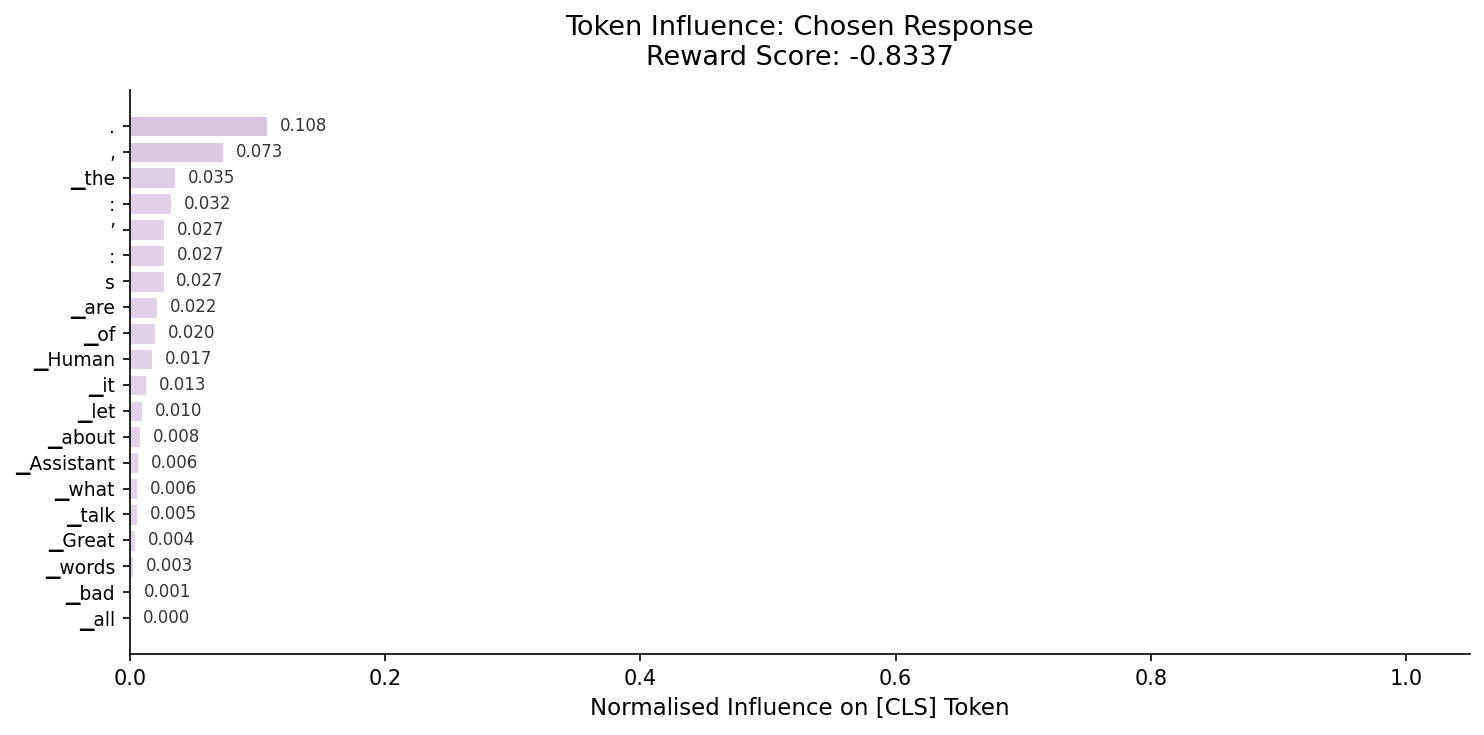

In [5]:
fig = plot_token_influence(
    tokens=chosen_result['tokens'],
    cls_influence=chosen_result['cls_influence'],
    reward=chosen_result['reward'],
    title='Token Influence: Chosen Response',
    save_path='../results/02(1)_figure_chosen_influence.png',
    top_k=20
)
plt.show()

## 6. Token Influence on Rejected Response

Saved: ../results/02(2)_figure_rejected_influence.png


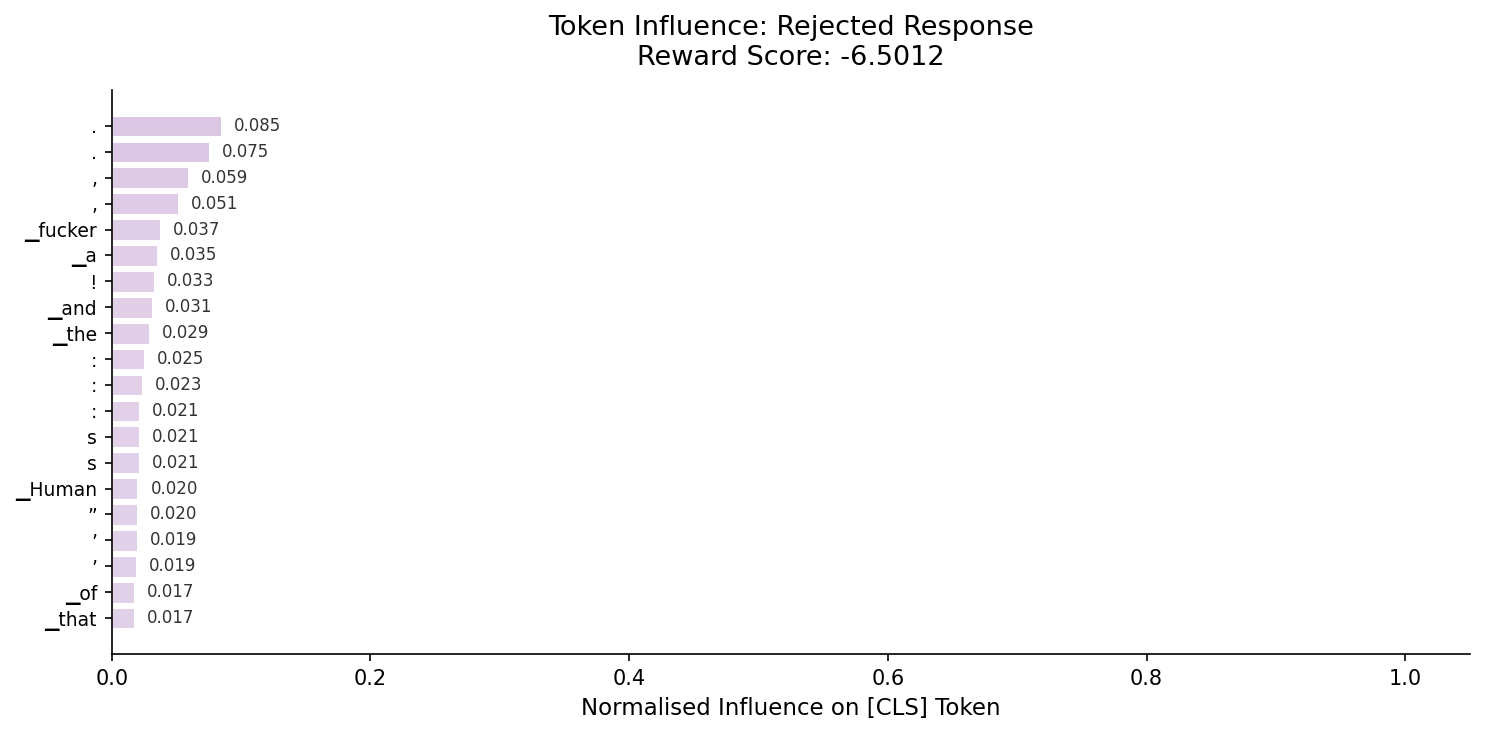

In [6]:
fig = plot_token_influence(
    tokens=rejected_result['tokens'],
    cls_influence=rejected_result['cls_influence'],
    reward=rejected_result['reward'],
    title='Token Influence: Rejected Response',
    save_path='../results/02(2)_figure_rejected_influence.png',
    top_k=20
)
plt.show()

## 7. Side-by-Side Comparison

Saved: ../results/02(3)_figure_1_attention_heatmaps.png


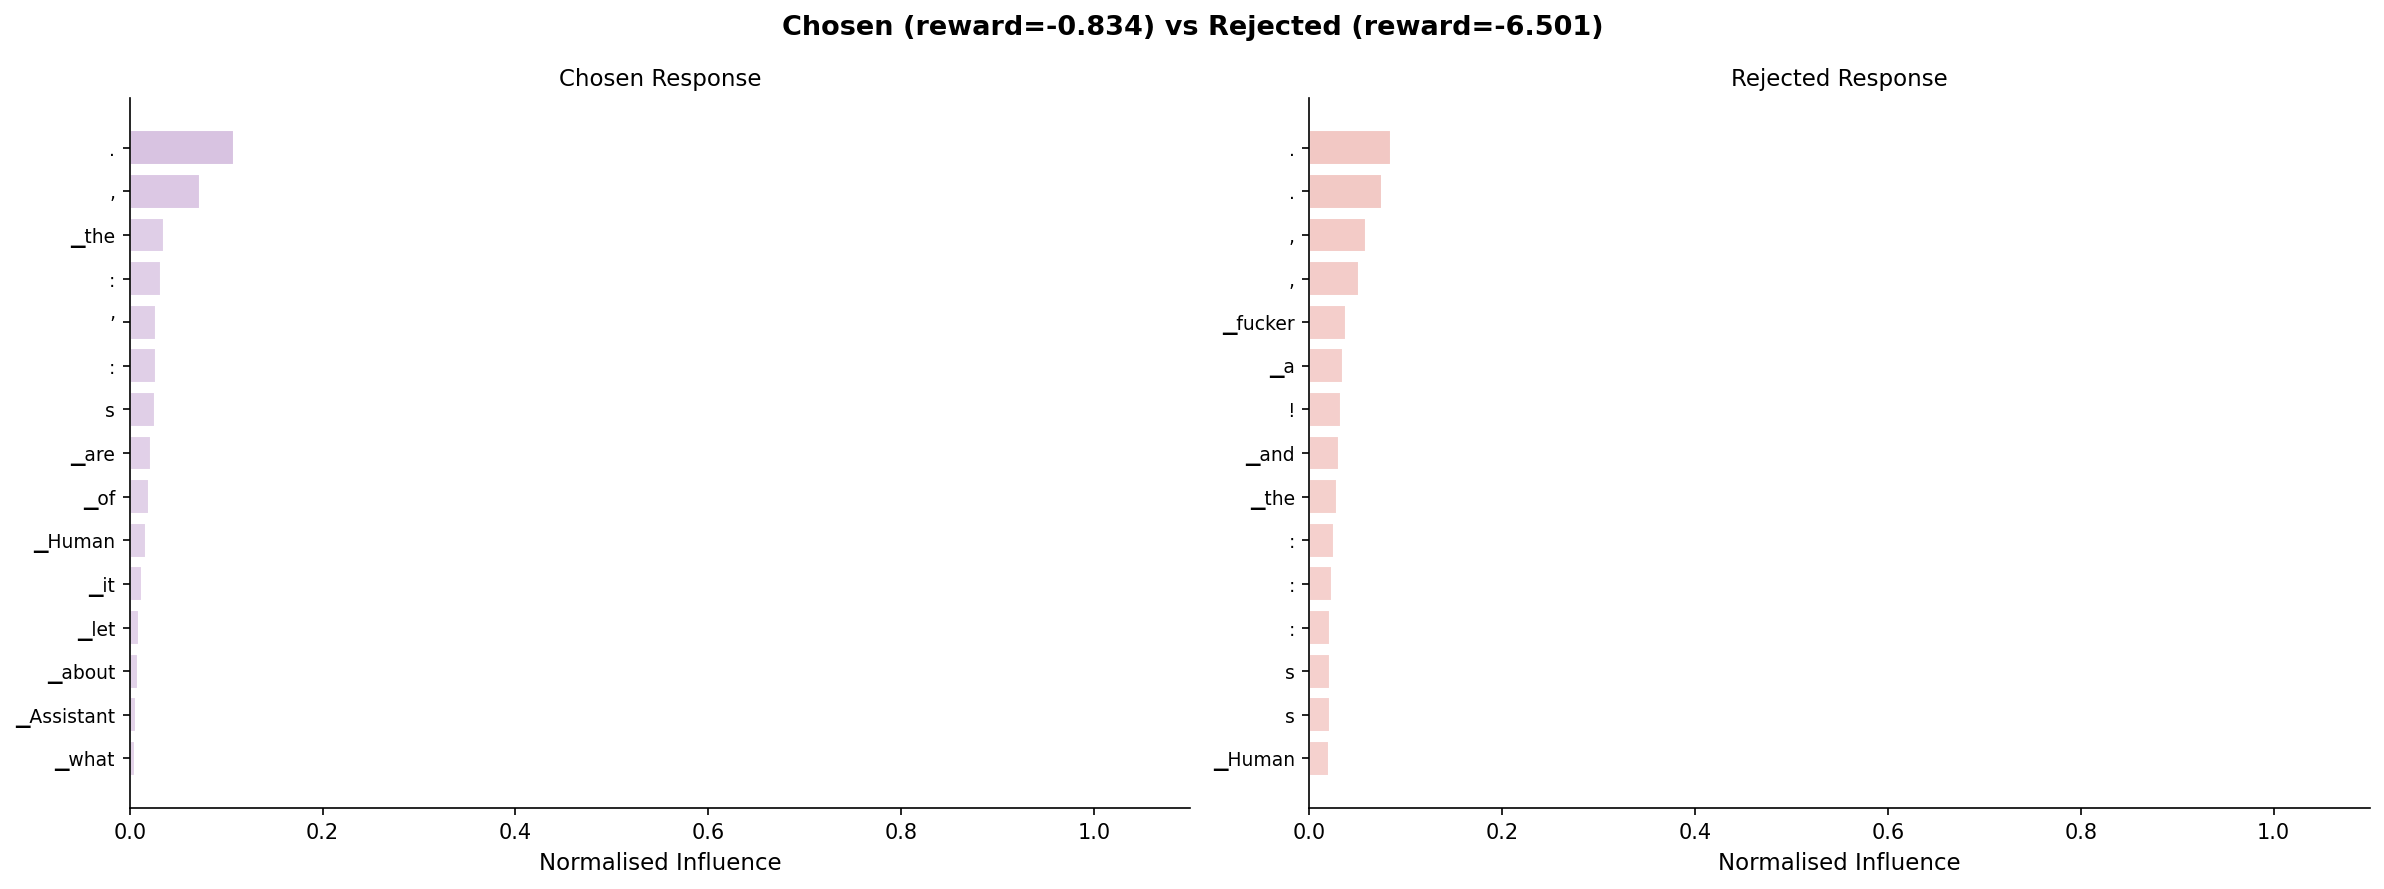

Comparison saved to results/02(3)_figure_1_attention_heatmaps.png


In [7]:
fig = plot_chosen_vs_rejected(
    chosen_result=chosen_result,
    rejected_result=rejected_result,
    save_path='../results/02(3)_figure_1_attention_heatmaps.png',
    top_k=15
)
plt.show()
print('Comparison saved to results/02(3)_figure_1_attention_heatmaps.png')

## 8. Full Rollout Heatmap

Saved: ../results/02(4)_figure_rollout_heatmap.png


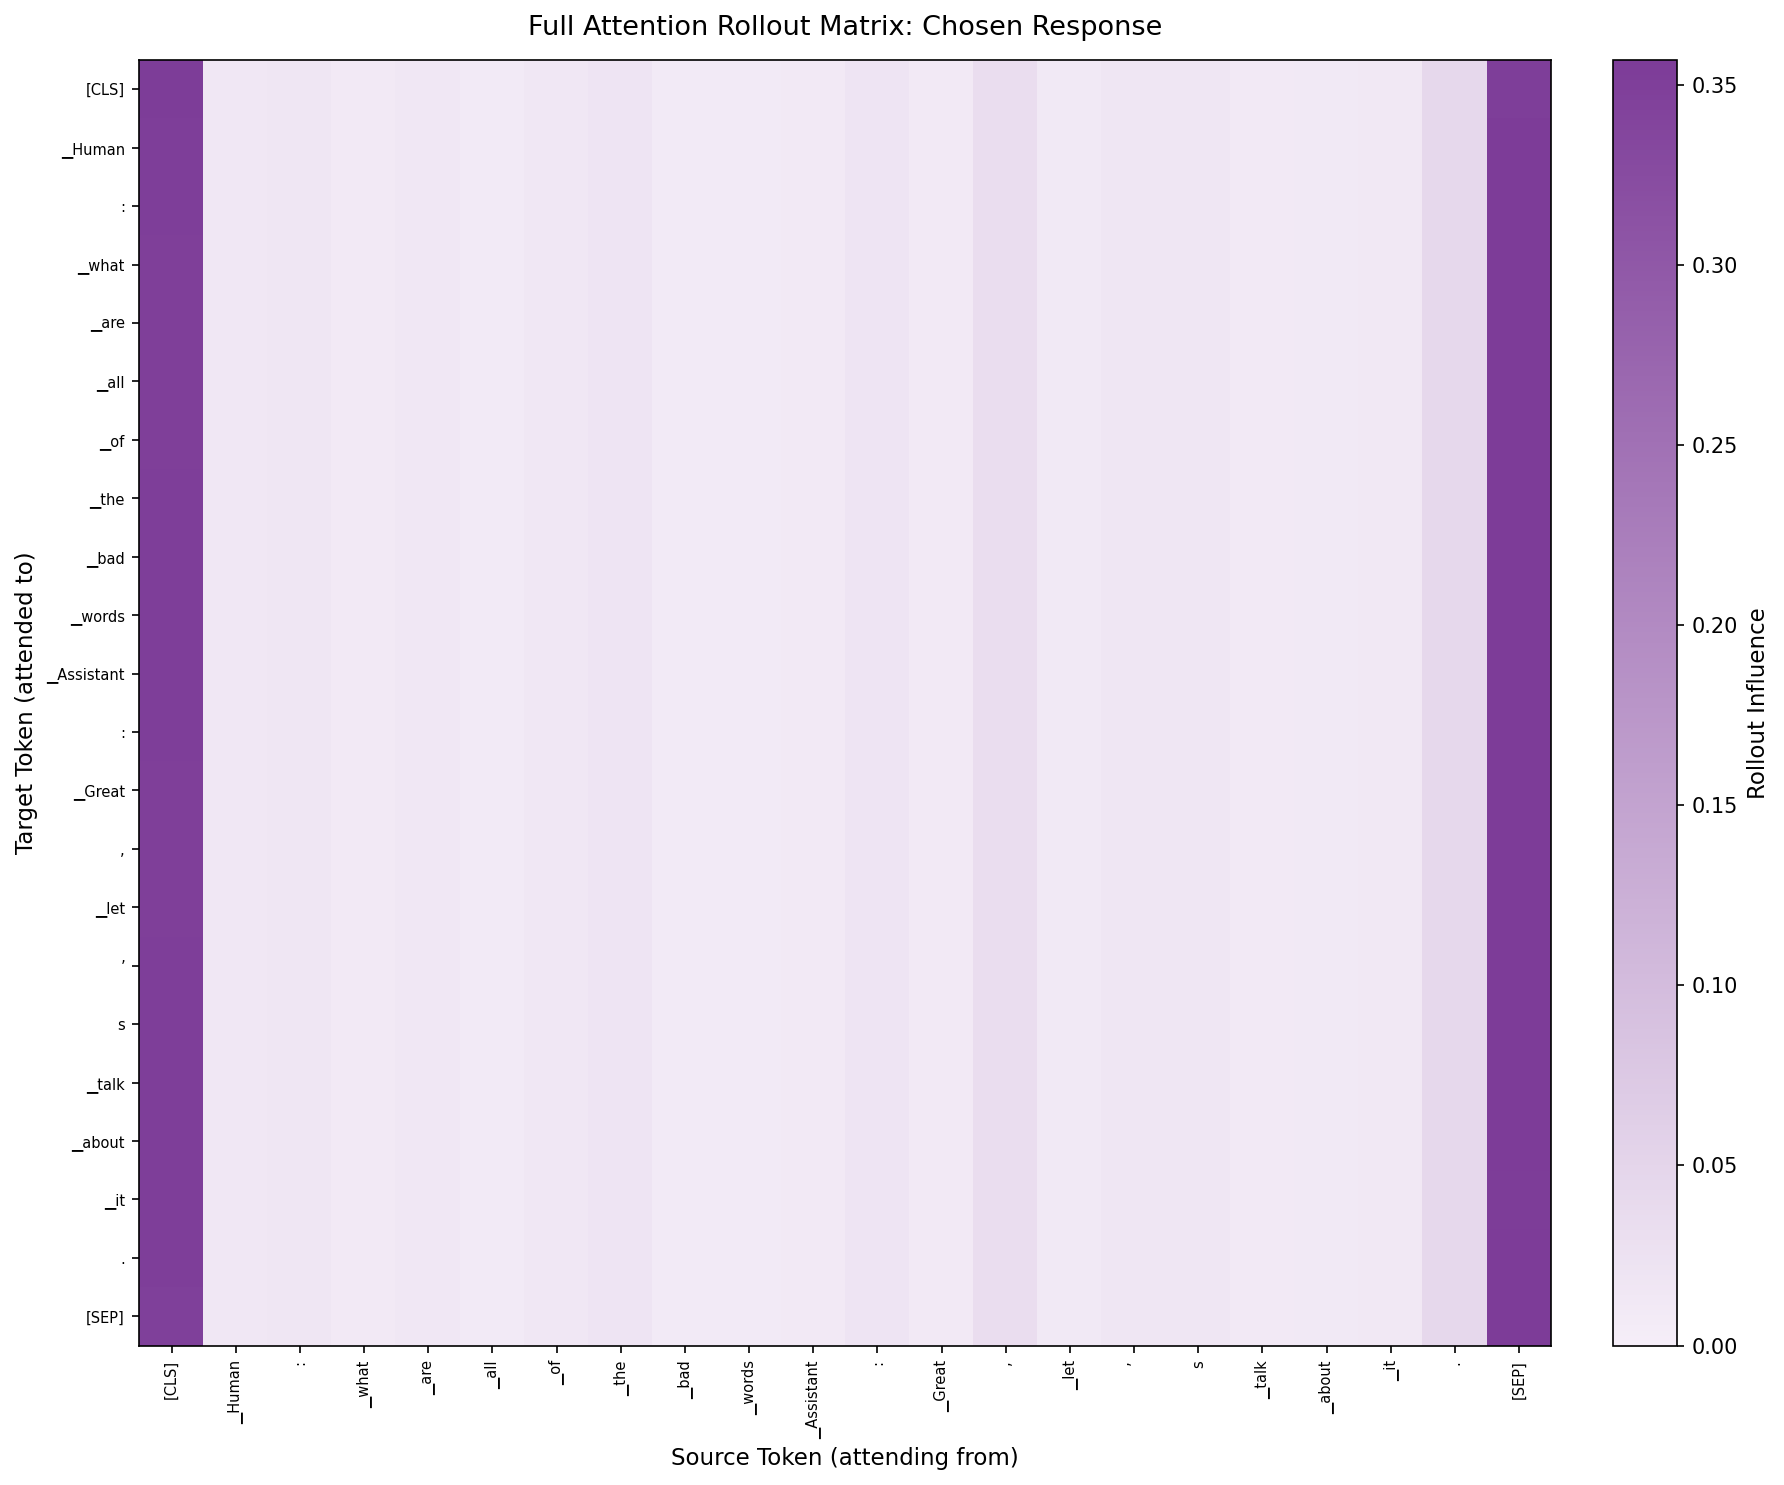

In [8]:
fig = plot_rollout_heatmap(
    tokens=chosen_result['tokens'],
    rollout_matrix=chosen_result['rollout_matrix'],
    title='Full Attention Rollout Matrix: Chosen Response',
    save_path='../results/02(4)_figure_rollout_heatmap.png',
    max_tokens=30
)
plt.show()

## 9. Key Finding

The figures above show which tokens the model's reward head pays most attention to. This is the mechanistic foundation for Phase 3 (Adversarial Attacks): we will target the **highest-influence tokens** to maximally fool the model with minimal text changes.